In [39]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)


In [40]:
df = pd.read_csv('missing_imputeted_df.csv')
df.head()

,colony,property_type,price_outer,price_per_sqft,Total Floors,Property Age,bedrooms,bathrooms,balconies,built_up_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,bhopal,House,105.0,3750,1.0,Old Property,7,5,0,2800.0,0,0,0,0,0,0,1,71,Green View Homes
1,kolar road,Flat,85.0,6508,2.0,New Property,3,3,1,1567.2,0,0,0,1,0,1,1,35,Green View Homes
2,katara hills,Flat,25.0,2173,3.0,New Property,2,2,3,957.0,0,0,0,0,0,0,1,15,Green View Homes
3,aishbagh,House,65.0,5909,2.0,Old Property,4,5,1,2400.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,House,650.0,16250,3.0,New Property,6,6,2,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


In [41]:
df.shape

(1566, 19)

In [42]:
train_df = df.drop(columns=['price_per_sqft'])
train_df.head()

,colony,property_type,price_outer,Total Floors,Property Age,bedrooms,bathrooms,balconies,built_up_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,bhopal,House,105.0,1.0,Old Property,7,5,0,2800.0,0,0,0,0,0,0,1,71,Green View Homes
1,kolar road,Flat,85.0,2.0,New Property,3,3,1,1567.2,0,0,0,1,0,1,1,35,Green View Homes
2,katara hills,Flat,25.0,3.0,New Property,2,2,3,957.0,0,0,0,0,0,0,1,15,Green View Homes
3,aishbagh,House,65.0,2.0,Old Property,4,5,1,2400.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,House,650.0,3.0,New Property,6,6,2,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


# luxury score

<Axes: ylabel='luxury_score'>

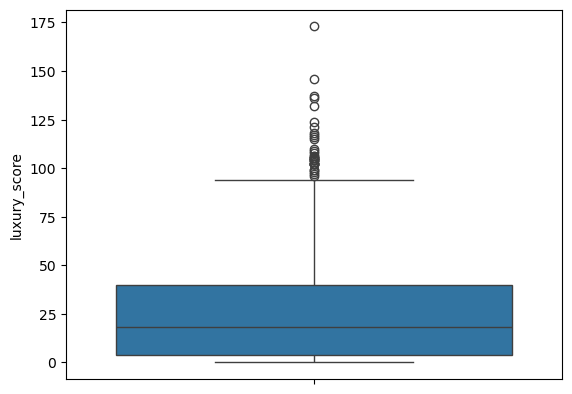

In [43]:
sns.boxplot(df['luxury_score'])

In [44]:
def categorize_luxury(score):
    if 0 <= score < 25:
        return "Low"
    elif 25 <= score < 100:
        return "Medium"
    elif 100 >= 100:
        return "High"
   

In [45]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [46]:
train_df.head()

,colony,property_type,price_outer,Total Floors,Property Age,bedrooms,bathrooms,balconies,built_up_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,luxury_category
0,bhopal,House,105.0,1.0,Old Property,7,5,0,2800.0,0,0,0,0,0,0,1,71,Green View Homes,Medium
1,kolar road,Flat,85.0,2.0,New Property,3,3,1,1567.2,0,0,0,1,0,1,1,35,Green View Homes,Medium
2,katara hills,Flat,25.0,3.0,New Property,2,2,3,957.0,0,0,0,0,0,0,1,15,Green View Homes,Low
3,aishbagh,House,65.0,2.0,Old Property,4,5,1,2400.0,0,0,0,1,0,0,0,18,Road Facing Homes,Low
4,chuna bhatti,House,650.0,3.0,New Property,6,6,2,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes,Low


# Total floors

<Axes: ylabel='Total Floors'>

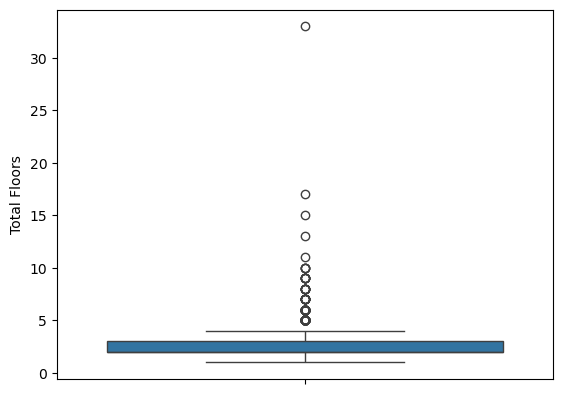

In [47]:
sns.boxplot(train_df['Total Floors'])

In [48]:
train_df['colony'].value_counts().shape # 37 unique colony

(37,)

In [49]:
train_df.drop(columns=['luxury_score'],inplace=True)

# Categorical columns encoding

In [50]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price_outer', axis=1)
y_label = data_label_encoded['price_outer']

[array(['aishbagh', 'arera colony', 'ashoka garden', 'awadhpuri',
       'ayodhya bypass', 'ayodhya nagar', 'bagmugaliya', 'bagmuliya',
       'bairagarh', 'bawadia kalan', 'bhopal', 'bypass road',
       'central bhopal', 'chuna bhatti', 'gandhinagar', 'gehu kheda',
       'govindpura', 'habib ganj', 'hoshangabad road', 'karond',
       'katara hills', 'khajuri kalan', 'kolar road', 'lalgathi',
       'mahawadiya', 'mandideep', 'misrod', 'navi bagh', 'neelbad',
       'outside bhopal', 'patel nagar', 'peer gate area', 'piplani',
       'salaiya', 'shahjahanabad', 'shahpura', 'shirdipuram'],
      dtype=object)]
[array(['Flat', 'House'], dtype=object)]
[array(['Moderate Property', 'New Property', 'Old Property',
       'Under Construction'], dtype=object)]
[array(['Amenity Facing Homes', 'Green View Homes', 'Premium Scenic Homes',
       'Road Facing Homes'], dtype=object)]
[array(['High', 'Low', 'Medium'], dtype=object)]


In [51]:
X_label

,colony,property_type,Total Floors,Property Age,bedrooms,bathrooms,balconies,built_up_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,Overlooking_Categories,luxury_category
0,10.0,1.0,1.0,2.0,7,5,0,2800.0,0,0,0,0,0,0,1,1.0,2.0
1,22.0,0.0,2.0,1.0,3,3,1,1567.2,0,0,0,1,0,1,1,1.0,2.0
2,20.0,0.0,3.0,1.0,2,2,3,957.0,0,0,0,0,0,0,1,1.0,1.0
3,0.0,1.0,2.0,2.0,4,5,1,2400.0,0,0,0,1,0,0,0,3.0,1.0
4,13.0,1.0,3.0,1.0,6,6,2,4000.0,1,1,1,1,0,0,2,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1561,12.0,0.0,1.0,2.0,2,2,1,1076.4,0,0,0,0,0,0,1,3.0,2.0
1562,2.0,1.0,1.0,1.0,3,2,1,750.0,0,0,0,0,0,0,1,3.0,2.0
1563,18.0,1.0,2.0,0.0,4,4,2,1800.0,0,0,0,0,0,0,2,0.0,1.0
1564,26.0,1.0,2.0,1.0,5,6,3,3400.0,0,0,0,0,0,0,1,0.0,1.0


In [52]:
y_label

0       105.0
1        85.0
2        25.0
3        65.0
4       650.0
        ...  
1561     80.0
1562     65.0
1563    155.0
1564    100.0
1565     35.0
Name: price_outer, Length: 1566, dtype: float64

# Technique 1 - Correlation Analysis

<Axes: >

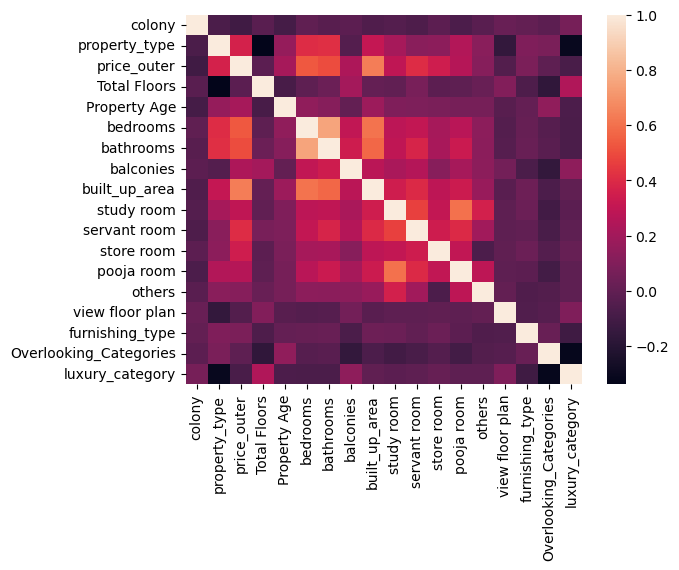

In [53]:
sns.heatmap(data_label_encoded.corr())

In [54]:
fi_df1 = data_label_encoded.corr()['price_outer'].drop('price_outer').reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,price_outer
0,colony,-0.111852
1,property_type,0.363207
2,Total Floors,-0.022329
3,Property Age,0.212505
4,bedrooms,0.532644
5,bathrooms,0.502486
6,balconies,0.235672
7,built_up_area,0.635748
8,study room,0.289606
9,servant room,0.408044


# Technique 2 - Random Forest Feature Importance

In [55]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
7,built_up_area,0.513703
0,colony,0.137511
4,bedrooms,0.071218
10,store room,0.059351
5,bathrooms,0.058707
2,Total Floors,0.023784
3,Property Age,0.021654
14,furnishing_type,0.018041
15,Overlooking_Categories,0.017944
16,luxury_category,0.017903


# Technique 3 - Gradient Boosting Feature importances

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
7,built_up_area,0.597655
0,colony,0.124705
10,store room,0.069556
4,bedrooms,0.065300
5,bathrooms,0.037470
9,servant room,0.024149
1,property_type,0.021061
3,Property Age,0.016652
14,furnishing_type,0.013168
16,luxury_category,0.006768


# Technique 4 - Permutation Importance

In [57]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
7,built_up_area,0.842780
5,bathrooms,0.075946
0,colony,0.051780
1,property_type,0.044467
10,store room,0.039907
9,servant room,0.016188
6,balconies,0.013381
4,bedrooms,0.009457
3,Property Age,0.009020
16,luxury_category,0.006891


# Technique 5 - LASSO

In [58]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
7,built_up_area,48.107328
4,bedrooms,17.788505
9,servant room,17.773650
10,store room,17.440980
1,property_type,16.939241
3,Property Age,8.624143
14,furnishing_type,6.134558
6,balconies,6.089730
5,bathrooms,2.909851
2,Total Floors,2.040732


# Technique 6 - RFE

In [59]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
7,built_up_area,0.513269
0,colony,0.132703
4,bedrooms,0.080169
5,bathrooms,0.054782
10,store room,0.052661
2,Total Floors,0.025419
3,Property Age,0.021311
14,furnishing_type,0.021262
15,Overlooking_Categories,0.020033
16,luxury_category,0.016818


# Technique 7 - Linear Regression Weights

In [60]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
7,built_up_area,48.111899
4,bedrooms,17.789710
9,servant room,17.786717
10,store room,17.450514
1,property_type,16.952035
3,Property Age,8.630709
14,furnishing_type,6.143254
6,balconies,6.102312
5,bathrooms,2.907369
2,Total Floors,2.056552


# Technique 8 - SHAP

In [61]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[-21.22550951,   4.4550737 ,   3.62329828, ...,  -2.26366369,
         -4.24528618,   0.55121878],
       [ -5.18273077,  -9.90481506,  -2.10141486, ...,  -1.41729853,
          0.59171625,   0.47074064],
       [ -6.97673923,  -7.44903453,   0.23229334, ...,  -0.84985888,
         -0.22913473,  -0.46151391],
       ...,
       [ -8.23968346,  11.71378246,  -1.91712399, ...,  18.16710069,
          4.28713255,   0.81702576],
       [-24.94561935,   3.8637977 ,  -0.52885427, ...,  -3.80695558,
         -0.74115405,  -1.13683361],
       [  1.88779169, -18.90733762,  -0.75109897, ...,   1.32271374,
         -0.16774205,  -1.39102645]])

In [62]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
7,built_up_area,45.647203
5,bathrooms,10.358128
1,property_type,9.537208
0,colony,9.489220
4,bedrooms,9.042795
3,Property Age,4.895399
10,store room,3.494976
9,servant room,2.885584
14,furnishing_type,2.127343
2,Total Floors,1.733600


In [63]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [64]:
final_fi_df

,price_outer,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
colony,-0.111852,0.137511,0.124705,0.051780,-7.537055,0.132703,-7.544760,9.489220
property_type,0.363207,0.009960,0.021061,0.044467,16.939241,0.010577,16.952035,9.537208
Total Floors,-0.022329,0.023784,0.006341,-0.002188,2.040732,0.025419,2.056552,1.733600
Property Age,0.212505,0.021654,0.016652,0.009020,8.624143,0.021311,8.630709,4.895399
bedrooms,0.532644,0.071218,0.065300,0.009457,17.788505,0.080169,17.789710,9.042795
bathrooms,0.502486,0.058707,0.037470,0.075946,2.909851,0.054782,2.907369,10.358128
balconies,0.235672,0.015940,0.006223,0.013381,6.089730,0.014720,6.102312,1.320704
built_up_area,0.635748,0.513703,0.597655,0.842780,48.107328,0.513269,48.111899,45.647203
study room,0.289606,0.005459,0.003474,-0.001747,-2.695940,0.007202,-2.711716,0.443360


In [65]:
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [66]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area             0.563187
colony                    0.106386
bathrooms                 0.063586
bedrooms                  0.062299
store room                0.050142
property_type             0.034502
Property Age              0.022888
servant room              0.019580
Total Floors              0.014027
furnishing_type           0.013231
balconies                 0.012297
Overlooking_Categories    0.012060
luxury_category           0.012035
pooja room                0.005450
others                    0.004405
study room                0.003760
view floor plan           0.000165
dtype: float64

# we are going to drop  pooja room, study room, others , lets confirm it.

In [67]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [68]:
scores.mean()

0.6034736637515505

In [69]:
scores.std()

0.054894880658574216

In [70]:
# after droping columns
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room','view floor plan', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [71]:
scores.mean()

0.5922717194805505

In [72]:
scores.std()

0.06910131626994112

# there is no problem we can drop this columns : pooja room , view floor plan , study room , others

In [73]:
export_df = X_label.drop(columns=['pooja room', 'view floor plan','study room', 'others'])
export_df['price'] = y_label

In [74]:
export_df.to_csv('bpl_properties_post_feature_selection.csv', index=False)

In [75]:
export_df

,colony,property_type,Total Floors,Property Age,bedrooms,bathrooms,balconies,built_up_area,servant room,store room,furnishing_type,Overlooking_Categories,luxury_category,price
0,10.0,1.0,1.0,2.0,7,5,0,2800.0,0,0,1,1.0,2.0,105.0
1,22.0,0.0,2.0,1.0,3,3,1,1567.2,0,0,1,1.0,2.0,85.0
2,20.0,0.0,3.0,1.0,2,2,3,957.0,0,0,1,1.0,1.0,25.0
3,0.0,1.0,2.0,2.0,4,5,1,2400.0,0,0,0,3.0,1.0,65.0
4,13.0,1.0,3.0,1.0,6,6,2,4000.0,1,1,2,3.0,1.0,650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1561,12.0,0.0,1.0,2.0,2,2,1,1076.4,0,0,1,3.0,2.0,80.0
1562,2.0,1.0,1.0,1.0,3,2,1,750.0,0,0,1,3.0,2.0,65.0
1563,18.0,1.0,2.0,0.0,4,4,2,1800.0,0,0,2,0.0,1.0,155.0
1564,26.0,1.0,2.0,1.0,5,6,3,3400.0,0,0,1,0.0,1.0,100.0
